# 01 — Exploratory Data Analysis (EDA)

Public ESG datasets used in this study:

1. **`Dow30-DATASET-Q2_2024.csv`** — Dow 30 firms with ESG scores from
   three major raters (S&P Global, Sustainalytics, MSCI), Q2 2024.
2. **`data.csv`** — 700+ mid/large-cap firms, single-source ESG scores
   with letter grades (used for cut-off / distribution analysis).

This notebook inspects structure, missingness, scale direction, and
basic distributions. No modelling here.


Dow30 dataset
Shape: (30, 46)

Missingness in rater columns:
  SNP              non-null =  27 / 30
  Sustainalytics   non-null =  28 / 30
  MSCI             non-null =  27 / 30

Complete cases (all 3 raters present): n = 26

Scale ranges (raw):
  SNP            : 21.0 .. 81.0  (higher = better)
  Sustainalytics : 12.4 .. 39.6  (RISK: lower = better)
  MSCI (letters) : ['A', 'AA', 'AAA', 'BBB']
  corr(SNP, SNP_normalized) = +1.000  (aligned)
  corr(Sustainalytics, Sustainalytics_normalized) = +1.000  (aligned)
  corr(MSCI, MSCI_normalized) = +1.000  (aligned)

GICS sector composition (Dow 30):
GIC_sector
Information Technology    7
Industrials               4
Consumer Discretionary    4
Financials                4
Health Care               4
Consumer Staples          3
Communication Services    2
Materials                 1
Energy                    1

Broad dataset (data.csv)
Shape: (722, 21)

Score summary:
       environment_score  social_score  governance_score  total_score
count  

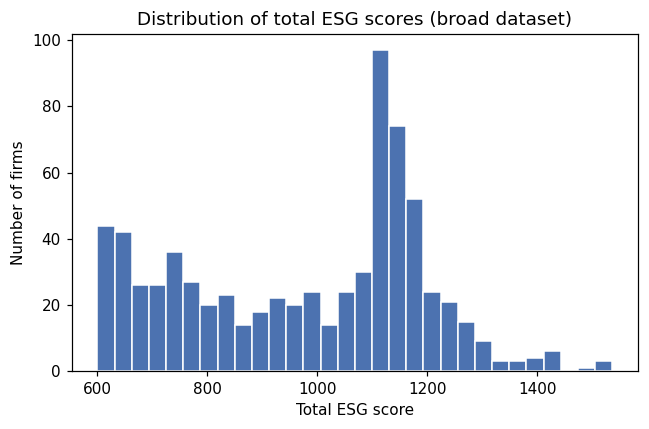

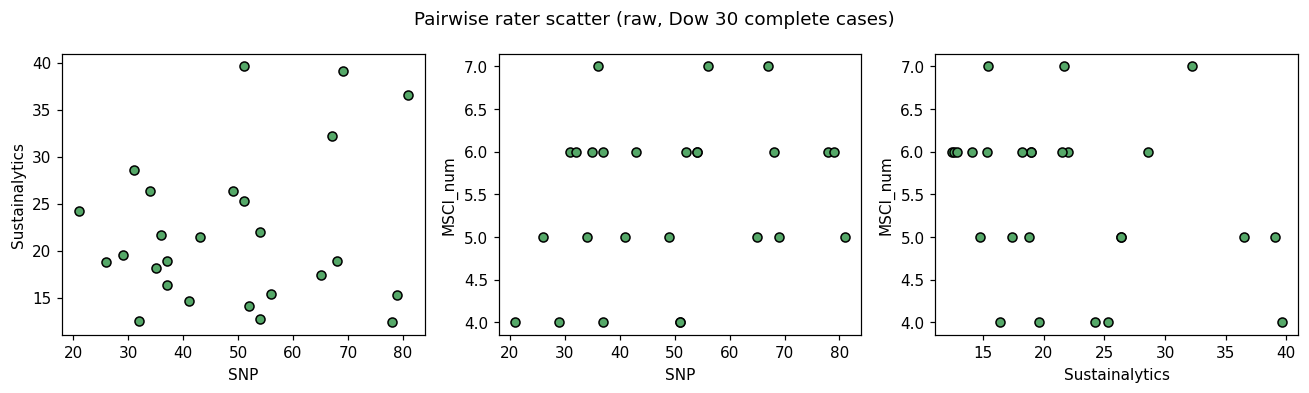


Saved EDA figures to results/figures/ and boundary table to results/table/.
EDA complete.


In [1]:
# ============================================================
# 01 — EDA for ESG scorecard validation
# Run from the notebooks/ folder. Repo layout:
#   notebooks/  data/  results/table/  results/figures/
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paths (relative to notebooks/) ----
DATA_DIR = os.path.join("..", "data")
FIG_DIR  = os.path.join("..", "results", "figures")
TAB_DIR  = os.path.join("..", "results", "table")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

DOW30 = os.path.join(DATA_DIR, "Dow30-DATASET-Q2_2024.csv")
BROAD = os.path.join(DATA_DIR, "data.csv")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# ============================================================
# PART A — Dow 30 multi-rater dataset
# ============================================================
dow = pd.read_csv(DOW30)
print("=" * 60)
print("Dow30 dataset")
print("=" * 60)
print("Shape:", dow.shape)

# The three rater columns we care about
rater_cols = ["SNP", "Sustainalytics", "MSCI"]
print("\nMissingness in rater columns:")
for c in rater_cols:
    print(f"  {c:16s} non-null = {dow[c].notna().sum():3d} / {len(dow)}")

# Complete-case subsample (all three raters present)
core = dow[["Symbol"] + rater_cols].dropna().copy()
print(f"\nComplete cases (all 3 raters present): n = {len(core)}")

# ---- Scale direction check (critical!) ----
# S&P Global : higher = better ESG            (0-100)
# Sustainalytics : ESG RISK score, LOWER = better
# MSCI : letter grade CCC..AAA (higher = better) -> map to 1..7
print("\nScale ranges (raw):")
print(f"  SNP            : {core['SNP'].min():.1f} .. {core['SNP'].max():.1f}  (higher = better)")
print(f"  Sustainalytics : {core['Sustainalytics'].min():.1f} .. {core['Sustainalytics'].max():.1f}  (RISK: lower = better)")
print(f"  MSCI (letters) : {sorted(core['MSCI'].unique())}")

# NOTE: the dataset ships *_normalized columns, but the Sustainalytics
# normalized column is NOT direction-flipped (it correlates +1.0 with the
# raw risk score). We therefore align directions manually in notebook 02.
msci_map_chk = {"CCC": 1, "B": 2, "BB": 3, "BBB": 4, "A": 5, "AA": 6, "AAA": 7}
for c in ["SNP", "Sustainalytics", "MSCI"]:
    nc = c + "_normalized"
    if nc in dow.columns:
        sub = dow[[c, nc]].dropna().copy()
        # MSCI is a letter grade -> map to numeric before correlating
        if c == "MSCI":
            sub[c] = sub[c].map(msci_map_chk)
        sub = sub.dropna()
        # coerce normalized column to numeric (guards against stray text)
        sub[nc] = pd.to_numeric(sub[nc], errors="coerce")
        sub = sub.dropna()
        if len(sub) > 1:
            r = sub[c].corr(sub[nc])
            print(f"  corr({c}, {nc}) = {r:+.3f}  "
                  f"({'aligned' if r > 0 else 'reversed'})")

# ---- Sector composition ----
if "GIC_sector" in dow.columns:
    print("\nGICS sector composition (Dow 30):")
    print(dow["GIC_sector"].value_counts().to_string())

# ============================================================
# PART B — Broad 700+ firm dataset
# ============================================================
broad = pd.read_csv(BROAD)
print("\n" + "=" * 60)
print("Broad dataset (data.csv)")
print("=" * 60)
print("Shape:", broad.shape)

score_cols = ["environment_score", "social_score",
              "governance_score", "total_score"]
print("\nScore summary:")
print(broad[score_cols].describe().round(1).to_string())

print("\nTotal grade distribution:")
print(broad["total_grade"].value_counts().to_string())

# Reverse-engineer the grade boundaries (min/max score per grade)
print("\nScore range per total_grade (reveals hard-coded cut-offs):")
bounds = (broad.groupby("total_grade")["total_score"]
          .agg(["min", "max", "count"]).sort_values("min"))
print(bounds.to_string())

# ============================================================
# PART C — Quick EDA figures (saved to results/figures/)
# ============================================================
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Fig 1: total_score histogram (broad dataset)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(broad["total_score"].dropna(), bins=30,
        color="#4C72B0", edgecolor="white")
ax.set_xlabel("Total ESG score")
ax.set_ylabel("Number of firms")
ax.set_title("Distribution of total ESG scores (broad dataset)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "eda_total_score_hist.png"),
            bbox_inches="tight")
plt.show()

# Fig 2: pairwise scatter of the three raters (raw, complete cases)
msci_map = {"CCC": 1, "B": 2, "BB": 3, "BBB": 4, "A": 5, "AA": 6, "AAA": 7}
core["MSCI_num"] = core["MSCI"].map(msci_map)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
pairs = [("SNP", "Sustainalytics"), ("SNP", "MSCI_num"),
         ("Sustainalytics", "MSCI_num")]
for ax, (a, b) in zip(axes, pairs):
    ax.scatter(core[a], core[b], color="#55A868", edgecolor="k", s=35)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
fig.suptitle("Pairwise rater scatter (raw, Dow 30 complete cases)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "eda_rater_scatter_raw.png"),
            bbox_inches="tight")
plt.show()

# Save a small EDA summary table
bounds.to_csv(os.path.join(TAB_DIR, "eda_grade_boundaries.csv"))
print("\nSaved EDA figures to results/figures/ and boundary table to results/table/.")
print("EDA complete.")
